# SEABORN 

El objetivo de esta actividad es generar un FacetGrid de Seaborn y poderlo interpretar de manera efectiva.



Instrucciones

Generar un estilo de Seaborn y aplicarlo a la visualización.
Crear un FacetGrid de una gráfica de su elección de Seaborn que esté dividida por Filas y columnas.  Los datos deben provenir de las mismas bases de datos utilizadas para el panel de visualización de Matplotlib.
Usa los métodos .map o map_dataframe para generar la gráfica.
Establece un título de la gráfica y de los ejes que sean autoexplicables. Considera los elementos de la unidad 1 y 2 para asegurar que sea una buena visualización.
Interpretar los resultados de la gráfica en un reporte de 1 cuartilla.


Enviar un archivo .pdf con la composición de gráficas (FacetGrid)  y su interpretación.


In [72]:
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
#descagar datos 
import yfinance as yf
#data frames
import pandas as pd 
#qur no me cancele y fincnce 
import time


In [73]:

tickers = [    "BTC-USD",    # Bitcoin
    "ETH-USD",    # Ethereum
    "DOGE-USD",   # Dogecoin
    "XRP-USD",    # XRP
    ]

def construirdfs(tickers):
    data = {}
    info_list = []
    for ticker in tickers:
        #descargar los datos 
        tkr = yf.Ticker(ticker) #declarar el ticker
        df = tkr.history(period="1y") #obtener la información historica 
        #volverlo un solo df con multiindex 
        df.drop(columns=["Dividends", "Stock Splits"], errors='ignore', inplace=True)  #no relevantes en el de ahorita quiza madure en el futuro y lo incluya
        df.columns = pd.MultiIndex.from_product([[ticker], df.columns])  #crear el multiindex de mi df solito
        data[ticker] = df #guardarlo
        #el df de la información 
        """info = tkr.info
        #los datos que me interesan
            #geocodificación para mapas haha 
        city = info.get('city', '')
        state = info.get('state', '')
        country = info.get('country', '')
        address = f"{city}, {state}, {country}"
        
        
        latitude, longitude = None, None
        try:
            location = geolocator.geocode(address)
            if location:
                latitude = location.latitude
                longitude = location.longitude
        except Exception as e:
            print(f"Error geocoding {ticker}: {e}")
        info_data = {
        'Ticker': ticker,
        'Name': info.get('longName'),
        'Sector': info.get('sector'),
        'Industry': info.get('industry'),
        'City': city,
        'State': state,
        'Country': country,
        'Exchange': info.get('exchange'),
        'Currency': info.get('currency'),
        'Address': address,
        'Latitude': latitude,
        'Longitude': longitude
        }

        info_list.append(info_data)"""
        
        time.sleep(0.5)  # para que yahoo no me cancele otra vez
    #hacer el merge solo una vez de los datos historicos 
    historicaldata = pd.concat(data.values(), axis=1)
    """#volver mi larga lista de atributos un solo df 
    infodata = pd.DataFrame(info_list).set_index('Ticker')"""
    return historicaldata

historicaldata = construirdfs( tickers )

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mantenemos la paleta de colores de seaborn que hayas elegido
sns.set_palette("viridis")

myModernStyle = {
    # Base del estilo whitegrid de seaborn
    'axes.facecolor': '#ffffff',
    'axes.grid': True,
    'grid.color': '#d3d3d3',
    'grid.linestyle': '-',
    'grid.alpha': 0.5,  # Grid transparente

    # Colores de los ejes (no azules)
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#555555',

    # Títulos de los plots en negritas
    'axes.titlesize': 'large',
    'axes.titleweight': 'bold',

    # Spines (similar al whitegrid)
    'axes.spines.right': False,
    'axes.spines.top': False,

    # Ticks
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'xtick.direction': 'out',
    'ytick.direction': 'out',

    # Líneas más delgadas y bolitas con alpha
    'lines.linewidth': 0.1,  # Líneas más delgadas
    'lines.markersize': 8,
    'markers.alpha': 0.1,  # Alpha para las bolitas

    # Eliminar el color del rededor de las bolitas
    'lines.markeredgewidth': 0,  # Sin borde alrededor de las bolitas
    'lines.markeredgecolor': 'none',  # Sin borde alrededor de las bolitas

    # Colores de las bolitas (similar al whitegrid)
    'lines.color': '#00104c',  # Color de las líneas y bolitas
    'lines.markerfacecolor': '#00104c',  # Color de las bolitas

    # Leyenda (similar al whitegrid)
    'legend.frameon': False,
    'legend.loc': 'best',

    # Fondo de figura blanco
    'figure.facecolor': 'white',

    # Tamaño del texto
    'font.size': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
}




In [75]:
df = historicaldata
# Change columns names to this ones

# tickers = [    "BTC-USD",    # Bitcoin
#     "ETH-USD",    # Ethereum
#     "USDC-USD",   # USD Coin
#     "XRP-USD",    # XRP
#     ]


df.columns = pd.MultiIndex.from_tuples([
    (ticker, col) for ticker in tickers for col in ['Open', 'High', 'Low', 'Close', 'Volume']
])

df.columns.levels

FrozenList([['BTC-USD', 'DOGE-USD', 'ETH-USD', 'XRP-USD'], ['Close', 'High', 'Low', 'Open', 'Volume']])

In [76]:
# Nombres bonitos para los indices
df = df.rename(columns={'BTC-USD': 'Bitcoin', 'ETH-USD': 'Ethereum', 'DOGE-USD': 'DOGECOIN', 'XRP-USD': 'XRP'}, level=0) # renombrar los tickers

df.columns.names = ['Ticker', 'Field'] # nombrar los indices 

df_long = df.stack(level=['Ticker', 'Field']).reset_index() # resetear índices como columnas

df_long.columns = ['Date', 'Ticker', 'Field', 'Value'] # nuevas columnas 

print(df_long.head())


                       Date   Ticker   Field         Value
0 2024-04-29 00:00:00+00:00  Bitcoin    Open  6.310636e+04
1 2024-04-29 00:00:00+00:00  Bitcoin    High  6.417488e+04
2 2024-04-29 00:00:00+00:00  Bitcoin     Low  6.179546e+04
3 2024-04-29 00:00:00+00:00  Bitcoin   Close  6.384112e+04
4 2024-04-29 00:00:00+00:00  Bitcoin  Volume  2.663591e+10


C:\Users\herie\AppData\Local\Temp\ipykernel_3884\1575926016.py:6: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_long = df.stack(level=['Ticker', 'Field']).reset_index() # resetear índices como columnas


In [77]:
# Drop the Open, high, and low
df_long = df_long[~df_long['Field'].isin(['Open', 'High', 'Low'])] # eliminar open, high y low

In [78]:
# Cambiar 'Close' a 'Precico' y 'Volume' a 'Volumen'
df_long['Field'] = df_long['Field'].replace({'Close': 'Precio', 'Volume': 'Volumen'}) # renombrar los campos

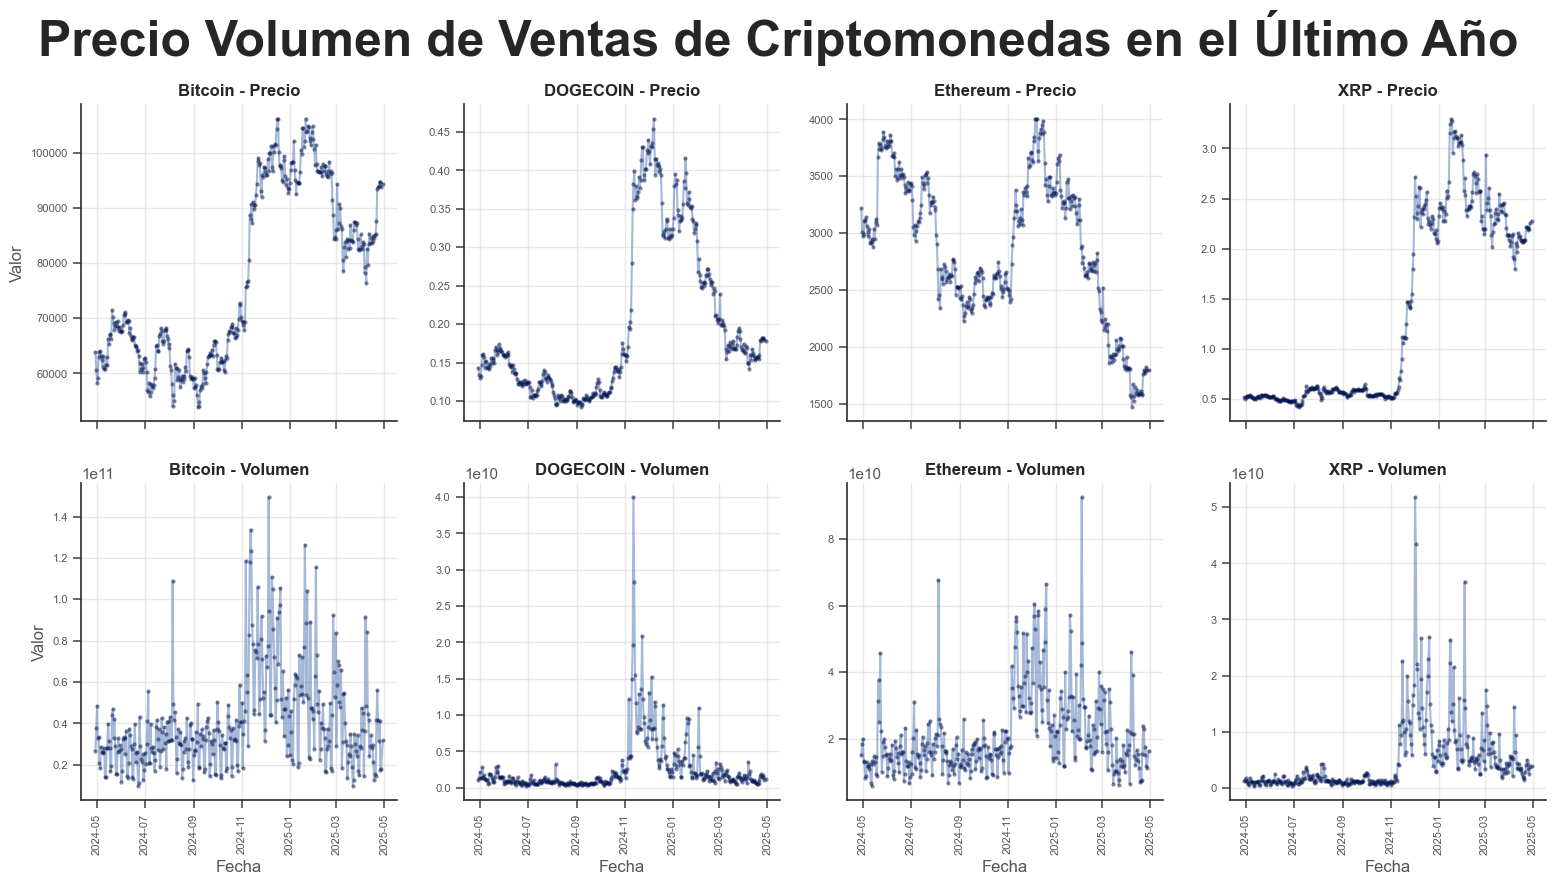

In [84]:

sns.set(style= myModernStyle) 

g = sns.FacetGrid(df_long, col='Ticker', row='Field', height=4, sharey=False)

#line
g.map(sns.lineplot, 'Date', 'Value', marker='o')

#title per plot 
g.set_axis_labels("Fecha", "Valor")
g.set_titles("{col_name} - {row_name}")

g.fig.suptitle('Precio Volumen de Ventas de Criptomonedas en el Último Año', fontsize=36, fontweight='bold', y=1.07) # título general

# Aplicar rotación de los labels en cada eje
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90, labelsize=8)  # Rotar etiquetas del eje x
    ax.tick_params(axis='y', labelsize=8)  # Cambiar tamaño de etiquetas del eje y

# Cambiar el color de las bolitas
for ax in g.axes.flat:
    for line in ax.lines:
        line.set_markerfacecolor('#00104c')  # Cambiar el color de las bolitas
        line.set_markeredgewidth(0)  # Sin borde alrededor de las bolitas
        line.set_alpha(0.5)
        line.set_markersize(3)


plt.savefig('cryptos.pdf', bbox_inches='tight', dpi=300) # guardar el plot como pdf
plt.show()